### Limpieza del fichero de calidad de vida en España. Seleccionando los datos de la Comunidad de Madrid 
## El fichero analizado es 07-datos_calidad_vida_multi.xlsx. Se carga desde Kaggle y se limpia y normalizan los datos

In [1]:
import altair as alt

# Desactivar vegafusion si quedó activado accidentalmente
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [2]:
!pip install reverse_geocoder

In [3]:
import pandas as pd
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
# Carga los datos raw disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets

file_path_07 = "07-datos_calidad_vida_multi.xlsx"

df_07 = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "raquelahdo/ruido-datasets",
  file_path_07
)


In [5]:
df_07.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CCAA    20 non-null     object 
 1   2008    20 non-null     float64
 2   2009    20 non-null     float64
 3   2010    20 non-null     float64
 4   2011    20 non-null     float64
 5   2012    20 non-null     float64
 6   2013    20 non-null     float64
 7   2014    20 non-null     float64
 8   2015    20 non-null     float64
 9   2016    20 non-null     float64
 10  2017    20 non-null     float64
 11  2018    20 non-null     float64
 12  2019    20 non-null     float64
 13  2020    20 non-null     float64
 14  2021    20 non-null     float64
 15  2022    20 non-null     float64
 16  2023    20 non-null     float64
 17  2024    20 non-null     float64
dtypes: float64(17), object(1)
memory usage: 2.9+ KB


In [6]:
#nombres de las pestañas del excel
df_07.keys()

Index(['CCAA',   2008,   2009,   2010,   2011,   2012,   2013,   2014,   2015,
         2016,   2017,   2018,   2019,   2020,   2021,   2022,   2023,   2024],
      dtype='object')

In [9]:
#Ubicacion del fichero excel descargado de Kaggle
import kagglehub

file_path_local = kagglehub.dataset_download(
    "raquelahdo/ruido-datasets"
)
file_path_local


'C:\\Users\\Raquel\\.cache\\kagglehub\\datasets\\raquelahdo\\ruido-datasets\\versions\\3'

In [10]:

# 1. Cargar todas las pestañas del Excel como diccionario de DataFrames
 #sheet_name=None = carga TODAS las hojas
 #df_07_raw será un diccionario: {"hoja1": df, "hoja2": df, ...}
ruta_excel = (
    file_path_local + "/07-datos_calidad_vida_multi.xlsx"
)
df_07_raw = pd.read_excel(ruta_excel, sheet_name=None)

# 2. Crear una lista donde almacenar los df filtrados
dfs_madrid = []

# 3. Recorrer cada pestaña
for hoja, df in df_07_raw.items():
    
    # Asegurar que la columna CCAA existe y tiene texto limpio
    if "CCAA" in df.columns:
        df["CCAA"] = df["CCAA"].astype(str).str.strip()
        
        # Filtrar solo Madrid, Comunidad de
        df_filtered = df[df["CCAA"] == "Madrid, Comunidad de"].copy()
        
        # Añadir columna con el nombre de la hoja, muy útil para análisis posteriores
        df_filtered["hoja"] = hoja
        
        # Guardar si no está vacío
        if not df_filtered.empty:
            dfs_madrid.append(df_filtered)

# 4. Concatenar todos los df filtrados en uno solo
df_07_Madrid = pd.concat(dfs_madrid, ignore_index=True)

df_07_Madrid.head(), df_07_Madrid.shape

(                   CCAA        2008        2009        2010        2011  \
 0  Madrid, Comunidad de   99.281388   99.073928   98.995333   99.861205   
 1  Madrid, Comunidad de  102.443179  101.286922  100.068555   98.786346   
 2  Madrid, Comunidad de  103.489366  103.026299  103.103050  103.627108   
 3  Madrid, Comunidad de  104.808559  104.300917  105.974979  108.170192   
 4  Madrid, Comunidad de  101.086655  101.086655  101.086655  101.086655   
 
          2012        2013        2014        2015        2016        2017  \
 0   99.068609   98.366696   98.653084   99.268873   98.964064   99.541366   
 1   98.199386   97.217032   97.754106   98.176490   98.303559   99.467470   
 2  105.494034  102.491987  105.122979  105.432678  106.334012  108.513085   
 3  107.496162  108.298555  107.807106  108.089664  108.526886  108.651639   
 4  101.086655  101.086655  101.086655  102.394647  102.394647  102.394647   
 
          2018        2019        2020        2021        2022        20

In [11]:
#en df_07_raw se han cargado localmente todas las pestañas de la excel original
df_07_raw.keys()

dict_keys(['Dimensión 1', 'Dimensión 2', 'Dimensión 3', 'Dimensión 4', 'Dimensión 5', 'Dimensión 6', 'Dimensión 7', 'Dimensión 8', 'Dimensión 9', 'Nacional_CCAA_dim', 'AMPI_Global', 'Evolución'])

In [12]:
#Extraemos la pestaña evolución
df_07_evolucion = df_07_raw["Evolución"].copy()

df_07_evolucion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dim     10 non-null     object 
 1   2008    10 non-null     int64  
 2   2009    10 non-null     float64
 3   2010    10 non-null     float64
 4   2011    10 non-null     float64
 5   2012    10 non-null     float64
 6   2013    10 non-null     float64
 7   2014    10 non-null     float64
 8   2015    10 non-null     float64
 9   2016    10 non-null     float64
 10  2017    10 non-null     float64
 11  2018    10 non-null     float64
 12  2019    10 non-null     float64
 13  2020    10 non-null     float64
 14  2021    10 non-null     float64
 15  2022    10 non-null     float64
 16  2023    10 non-null     float64
 17  2024    10 non-null     float64
dtypes: float64(16), int64(1), object(1)
memory usage: 1.5+ KB


In [13]:
df_07_evolucion.head()

,dim,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Global,100,99.634569,99.965132,100.259843,100.162563,99.910831,100.089989,100.366085,100.650384,101.096816,101.584055,101.906592,101.633697,101.559293,101.138772,101.202614,101.467223
1,1. Condiciones materiales de vida,100,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
2,2. Trabajo,100,98.345879,97.299442,95.990293,95.026675,94.076989,94.485209,95.273782,96.111272,97.231544,98.958235,99.747189,99.923761,99.627699,100.830857,101.756664,102.335092
3,3. Salud,100,99.225387,100.231553,101.656364,101.568570,100.552128,101.827690,101.969652,102.607827,103.568939,102.881003,103.869402,102.048269,101.298106,103.069806,101.855348,103.285736
4,4. Educación,100,100.110585,101.174039,101.844575,102.276487,102.844659,102.597361,103.020490,103.350113,103.840667,104.547002,105.032833,105.865870,108.420165,108.998673,109.567866,110.112882


In [14]:
df_07_Madrid.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,hoja
0,"Madrid, Comunidad de",99.281388,99.073928,98.995333,99.861205,99.068609,98.366696,98.653084,99.268873,98.964064,99.541366,100.490067,101.042230,100.341117,100.244256,100.663699,100.694292,100.392714,Dimensión 1
1,"Madrid, Comunidad de",102.443179,101.286922,100.068555,98.786346,98.199386,97.217032,97.754106,98.176490,98.303559,99.467470,101.094265,102.040018,101.949573,101.896527,102.562630,103.439218,104.155571,Dimensión 2
2,"Madrid, Comunidad de",103.489366,103.026299,103.103050,103.627108,105.494034,102.491987,105.122979,105.432678,106.334012,108.513085,105.886130,108.111280,104.024469,104.006636,106.388545,104.335901,105.449334,Dimensión 3
3,"Madrid, Comunidad de",104.808559,104.300917,105.974979,108.170192,107.496162,108.298555,107.807106,108.089664,108.526886,108.651639,108.892133,109.861059,111.008167,112.861069,113.545969,112.890669,113.492921,Dimensión 4
4,"Madrid, Comunidad de",101.086655,101.086655,101.086655,101.086655,101.086655,101.086655,101.086655,102.394647,102.394647,102.394647,99.109254,99.109254,99.109254,98.552799,95.350110,95.407400,95.204588,Dimensión 5


In [15]:
df_07_Madrid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CCAA    10 non-null     object 
 1   2008    10 non-null     float64
 2   2009    10 non-null     float64
 3   2010    10 non-null     float64
 4   2011    10 non-null     float64
 5   2012    10 non-null     float64
 6   2013    10 non-null     float64
 7   2014    10 non-null     float64
 8   2015    10 non-null     float64
 9   2016    10 non-null     float64
 10  2017    10 non-null     float64
 11  2018    10 non-null     float64
 12  2019    10 non-null     float64
 13  2020    10 non-null     float64
 14  2021    10 non-null     float64
 15  2022    10 non-null     float64
 16  2023    10 non-null     float64
 17  2024    10 non-null     float64
 18  hoja    10 non-null     object 
dtypes: float64(17), object(2)
memory usage: 1.6+ KB


### NORMALIZAMOS LOS DATOS DE df_07_evolucion y df_07_Madrid
# Teniendo en cuenta que:

# -En df_07_evolucion la primera columna "dim" identifica la dimensión o indicador.
# -En df_07_Madrid esa misma información aparece en la columna "hoja" (por ejemplo "Dimensión 1", "Dimensión 2", etc.).
# -Los demás valores (2008–2024) son series temporales y deben alinearse para poder comparar España (evolución) vs Madrid (CCAA)
# El objetivo es dejar ambos datasets limpios, comparables y con estructura larga (“tidy data”), con columnas:
# dimension   año   valor_evolucion   valor_madrid


In [17]:
#Normalizamos df_07_evolución

import pandas as pd

# --- Limpiar y renombrar columna dimension ---
df_07_evolucion_clean = df_07_evolucion.copy()

# Normalizamos el texto de 'dim'
df_07_evolucion_clean["dim"] = (
    df_07_evolucion_clean["dim"]
    .astype(str)
    .str.strip()
)

# Convertir de formato ancho → formato largo
df_07_evolucion_long = df_07_evolucion_clean.melt(
    id_vars=["dim"],
    var_name="año",
    value_name="valor_evolucion"
)

# Asegurar que 'año' es entero y valores numéricos
df_07_evolucion_long["año"] = df_07_evolucion_long["año"].astype(int)
df_07_evolucion_long["valor_evolucion"] = pd.to_numeric(df_07_evolucion_long["valor_evolucion"], errors="coerce")

df_07_evolucion_long.head()

,dim,año,valor_evolucion
0,Global,2008,100.0
1,1. Condiciones materiales de vida,2008,100.0
2,2. Trabajo,2008,100.0
3,3. Salud,2008,100.0
4,4. Educación,2008,100.0


In [18]:
df_07_evolucion_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dim              170 non-null    object 
 1   año              170 non-null    int64  
 2   valor_evolucion  170 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.1+ KB


In [19]:
#Normalizamos df_07_Madrid
#Limpieza y transformación:
df_07_Madrid_clean = df_07_Madrid.copy()

# Limpieza de la columna 'hoja' para que coincida con 'dim'
df_07_Madrid_clean["hoja"] = (
    df_07_Madrid_clean["hoja"]
    .astype(str)
    .str.strip()
)

# Pasar wide → long
df_07_Madrid_long = df_07_Madrid_clean.melt(
    id_vars=["hoja", "CCAA"],
    var_name="año",
    value_name="valor_madrid"
)

# Convertir tipos
df_07_Madrid_long["año"] = df_07_Madrid_long["año"].astype(int)
df_07_Madrid_long["valor_madrid"] = pd.to_numeric(df_07_Madrid_long["valor_madrid"], errors="coerce")



In [21]:
#Normalizar los nombres de dimensión entre ambas df
#df_07_evolución → "1. Condiciones materiales de vida", "2. Trabajo", …
#df_07_Madrid → "Dimensión 1", "Dimensión 2", …

df_07_evolucion_long["dim_num"] = (
    df_07_evolucion_long["dim"]
    .str.extract(r"^(\d+)")
    .astype(float)
)

df_07_Madrid_long["dim_num"] = (
    df_07_Madrid_long["hoja"]
    .str.extract(r"(\d+)")
    .astype(float)
)

# ambas tablas tienen la columna dim_num, que podemos usar para unir datos.

df_07_final = df_07_evolucion_long.merge(
    df_07_Madrid_long,
    on=["dim_num", "año"],
    how="inner",
    suffixes=("_espana", "_madrid")
)
#genera una tabla con:
#dim                     # nombre completo dimensión
#hoja                    # Dimensión 1,2,3...
#año
#valor_evolucion         # valor nacional
#valor_madrid            # valor Madrid CCAA

df_07_final.head()

,dim,año,valor_evolucion,dim_num,hoja,CCAA,valor_madrid
0,Global,2008,100.0,NaN,AMPI_Global,"Madrid, Comunidad de",100.656936
1,1. Condiciones materiales de vida,2008,100.0,1.0,Dimensión 1,"Madrid, Comunidad de",99.281388
2,2. Trabajo,2008,100.0,2.0,Dimensión 2,"Madrid, Comunidad de",102.443179
3,3. Salud,2008,100.0,3.0,Dimensión 3,"Madrid, Comunidad de",103.489366
4,4. Educación,2008,100.0,4.0,Dimensión 4,"Madrid, Comunidad de",104.808559


HABILITAR LA GESTIÓN MASIVA DE DATOS
The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

In [22]:
pip install "vegafusion[embed]>=1.5.0"

Note: you may need to restart the kernel to use updated packages.


In [23]:
 pip install "vl-convert-python>=1.6.0"

Note: you may need to restart the kernel to use updated packages.


### VISUALIZACIONES

In [24]:
df_07_final.columns[df_07_final.columns.duplicated()]

Index([], dtype='object')

In [25]:
#Eliminamos columnas duplicadas
df_07_final = df_07_final.loc[:, ~df_07_final.columns.duplicated()]

In [26]:
df_07_final.head()

,dim,año,valor_evolucion,dim_num,hoja,CCAA,valor_madrid
0,Global,2008,100.0,NaN,AMPI_Global,"Madrid, Comunidad de",100.656936
1,1. Condiciones materiales de vida,2008,100.0,1.0,Dimensión 1,"Madrid, Comunidad de",99.281388
2,2. Trabajo,2008,100.0,2.0,Dimensión 2,"Madrid, Comunidad de",102.443179
3,3. Salud,2008,100.0,3.0,Dimensión 3,"Madrid, Comunidad de",103.489366
4,4. Educación,2008,100.0,4.0,Dimensión 4,"Madrid, Comunidad de",104.808559


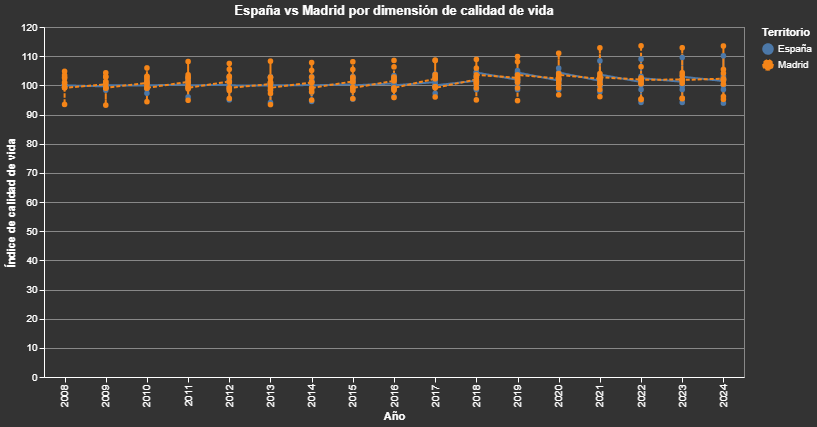

In [28]:
# VISUALIZACIÓN 1: GRÁFICO ESPAÑA vs MADRID POR DIMENSIÓN (líneas comparativas)
df_plot = df_07_final.copy()

df_plot_long = df_plot.melt(
    id_vars=["dim", "hoja", "año", "dim_num"],
    value_vars=["valor_evolucion", "valor_madrid"],
    var_name="territorio",
    value_name="valor"
)

df_plot_long["territorio"] = df_plot_long["territorio"].replace({
    "valor_evolucion": "España",
    "valor_madrid": "Madrid"
})


dchart_dim = (
    alt.Chart(df_plot_long)
    .mark_line(point=True)
    .encode(
        x=alt.X("año:O", title="Año"),
        y=alt.Y("valor:Q", title="Índice de calidad de vida"),
        color=alt.Color("territorio:N", title="Territorio"),
        strokeDash=alt.StrokeDash("territorio:N"),
        tooltip=["dim:N", "territorio:N", "año:O", "valor:Q"]
    )
    .properties(
        width=700,
        height=350,
        title="España vs Madrid por dimensión de calidad de vida"
    )
)

dchart_dim


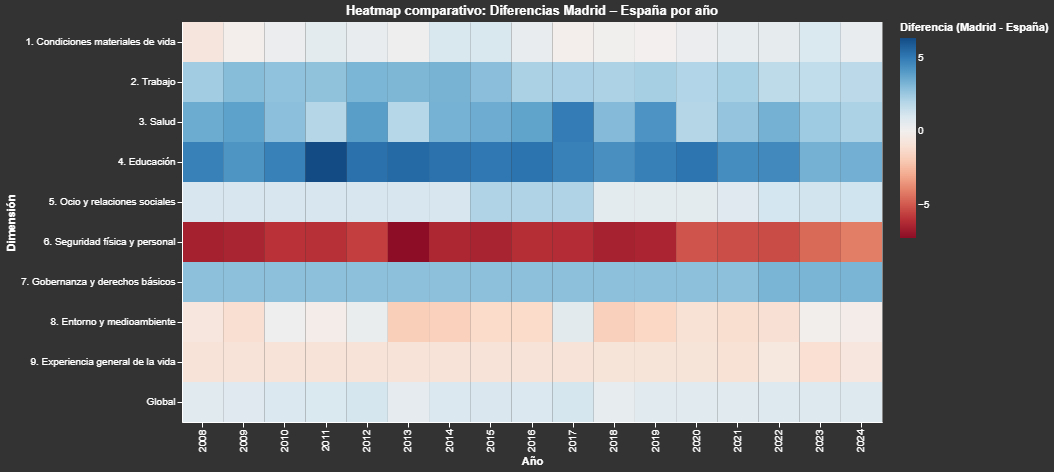

In [29]:
# VISUALIZACIÓN 2: HEATMAP COMPARATIVO POR AÑO Y DIMENSIÓN
#Muestra cuándo Madrid está por encima o por debajo del valor estatal.

df_heat = df_07_final.copy()
df_heat["diferencia"] = df_heat["valor_madrid"] - df_heat["valor_evolucion"]

chart_heat = (
    alt.Chart(df_heat)
    .mark_rect()
    .encode(
        x=alt.X("año:O", title="Año"),
        y=alt.Y("dim:N", title="Dimensión"),
        color=alt.Color("diferencia:Q",
                        title="Diferencia (Madrid - España)",
                        scale=alt.Scale(scheme="redblue", domainMid=0)),
        tooltip=["dim", "año", "valor_evolucion", "valor_madrid", "diferencia"]
    )
    .properties(
        width=700,
        height=400,
        title="Heatmap comparativo: Diferencias Madrid – España por año"
    )
)

chart_heat

# Rojo → Madrid peor
# Azul → Madrid mejor
# Blanco → Igual


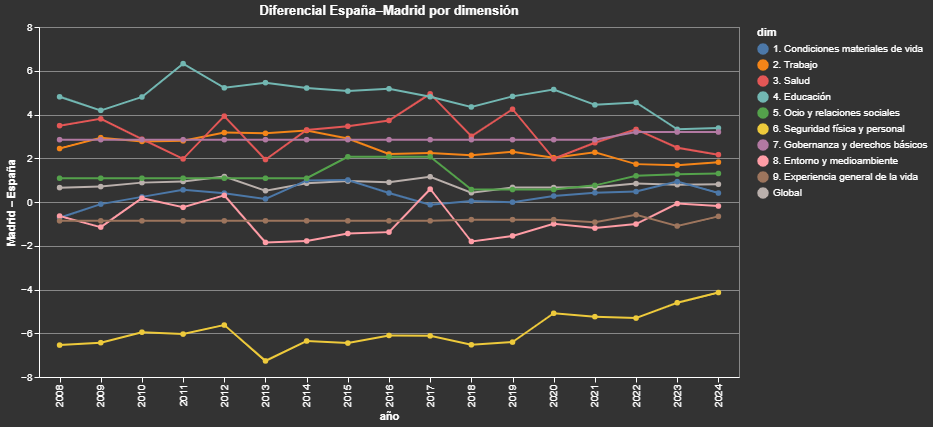

In [30]:
#VISUALIZACIÓN 3: DIFERENCIAL ESPAÑA – MADRID (líneas)
# Línea con diferencial por año y dimensión

chart_diff = (
    alt.Chart(df_heat)
    .mark_line(point=True)
    .encode(
        x="año:O",
        y=alt.Y("diferencia:Q", title="Madrid – España"),
        color="dim:N",
        tooltip=["dim", "año", "diferencia"]
    )
    .properties(
        width=700,
        height=350,
        title="Diferencial España–Madrid por dimensión"
    )
)

chart_diff


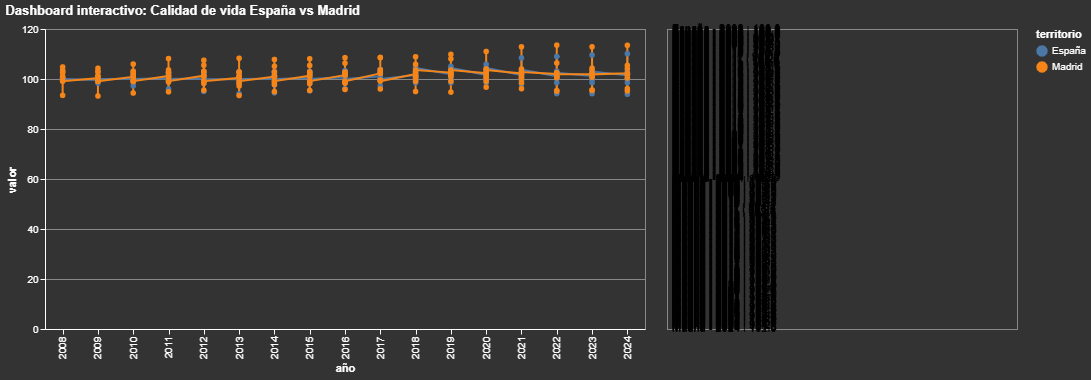

In [31]:
#VSUALIZACIÓN 3: DASHBOARD INTERACTIVO (Dimensión × Año)
# Selector de dimensión
selector_dim = alt.param(
    name="DimensiOn",
    bind=alt.binding_select(options=sorted(df_07_final["dim"].unique())),
    value=sorted(df_07_final["dim"].unique())[0]
)

# Gráfico España vs Madrid (interactivo)
chart_line = (
    alt.Chart(df_plot_long)
    .transform_filter(selector_dim)
    .mark_line(point=True)
    .encode(
        x="año:O",
        y="valor:Q",
        color="territorio:N",
        tooltip=["dim", "territorio", "año", "valor"]
    )
    .properties(width=600, height=300)
)

chart_table = (
    alt.Chart(df_plot_long)
    .transform_filter(selector_dim)
    .mark_text(align="left")
    .encode(
        x=alt.value(5),
        y=alt.Y("row_number:O", axis=None),
        text="texto:N"
    )
    .transform_window(row_number="row_number()")
    .transform_calculate(
        texto="join([datum.territorio, ' - ' , datum.año, ' : ', format(datum.valor,'0.1f')], '')"
    )
    .properties(width=350, height=300)
)

# Dashboard final
dashboard = (chart_line | chart_table).add_params(selector_dim).properties(
    title="Dashboard interactivo: Calidad de vida España vs Madrid"
)

dashboard



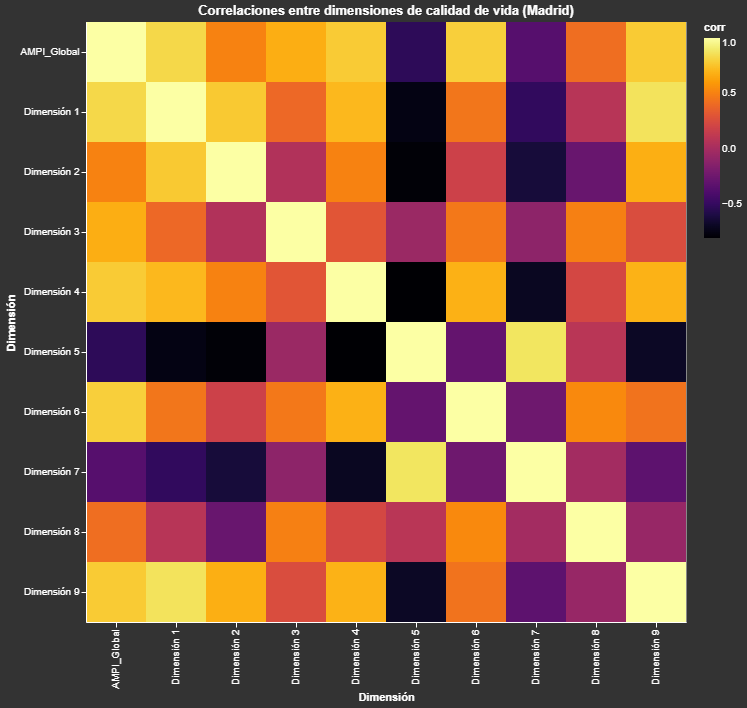

In [32]:
# CORRELACIONES SIGNIFICATIVAS
#(entre dimensiones de calidad de vida en Madrid)
# Matriz de correlación usando Madrid (solo valores madrid)
import pandas as pd

# 1. Seleccionamos datos de Madrid
df_cor = df_07_Madrid.copy()

# 2. Renombramos la columna hoja para evitar colisiones
df_cor = df_cor.rename(columns={"hoja": "dimension"})

# 3. Eliminamos columnas no numéricas
df_cor_clean = df_cor.drop(columns=["CCAA"])

# 4. Convertimos todo a número
df_cor_clean = df_cor_clean.set_index("dimension").apply(pd.to_numeric, errors="coerce")

# 5. Calculamos correlación entre dimensiones
df_corr = df_cor_clean.T.corr()


# Heatmap Altair
#Permite saber qué dimensiones se correlacionan más:
#Salud ↔ Educación
#Condiciones materiales ↔ Trabajo
#Seguridad ↔ Cohesión,...
df_corr_reset = df_corr.reset_index().rename(columns={"index": "dimension"})

df_corr_long = df_corr_reset.melt(id_vars="dimension", var_name="dimension2", value_name="corr")

#heatmap
chart_corr = (
    alt.Chart(df_corr_long)
    .mark_rect()
    .encode(
        x=alt.X("dimension:N", title="Dimensión"),
        y=alt.Y("dimension2:N", title="Dimensión"),
        color=alt.Color("corr:Q", scale=alt.Scale(scheme="inferno")),
        tooltip=["dimension", "dimension2", alt.Tooltip("corr:Q", format=".3f")]
    )
    .properties(
        width=600,
        height=600,
        title="Correlaciones entre dimensiones de calidad de vida (Madrid)"
    )
)

chart_corr





In [ ]:
#Se guardan los datasets procesados en local, para la fase de análisis posterior

In [33]:
# ----------------------------------------------------------------------
# Guardar los DataFrames procesados localmente
# ----------------------------------------------------------------------
df_07.to_csv("df_07_calidad-vida_processed.csv", index=False)
df_07_Madrid.to_csv("df_07_Madrid-calidad-vida_processed.csv", index=False)
df_07_evolucion.to_csv("df_07_evolucion-calidad-vida_processed.csv", index=False)
df_07_evolucion_long.to_csv("df_07_evolucion-long-calidad-vida_processed.csv", index=False)
df_07_final.to_csv("df_07_final-calidad-vida_processed.csv", index=False)

